In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

# Load dataset
df = pd.read_csv('/content/AmesHousing.csv')
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Dataset Loaded: 2930 rows, 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,...,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,...,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,...,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,...,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,...,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,...,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [20]:
#  Define Features (X) and Target (y), Train/Validation/Test Split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training:   {len(X_train)} rows (60%)")
print(f"Validation: {len(X_val)} rows (20%)")
print(f"Test:       {len(X_test)} rows (20%)")

Training:   1758 rows (60%)
Validation: 586 rows (20%)
Test:       586 rows (20%)


In [21]:
# Feature Selection

numeric_features = ['Gr Liv Area', 'Garage Area', 'Year Built', 'Total Bsmt SF', 'Lot Area']
ordinal_features = ['Overall Qual', 'Overall Cond', 'Bsmt Qual']
nominal_features = ['Neighborhood', 'MS Zoning', 'Sale Condition']

selected_cols = numeric_features + ordinal_features + nominal_features
X_train = X_train[selected_cols]
X_val = X_val[selected_cols]
X_test = X_test[selected_cols]

In [22]:
# Handle Missing Values
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_features] = num_imputer.fit_transform(X_train[numeric_features])
X_val[numeric_features] = num_imputer.transform(X_val[numeric_features])
X_test[numeric_features] = num_imputer.transform(X_test[numeric_features])

cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = ordinal_features + nominal_features
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [23]:
# Encode and Scale
bsmt_qual_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_categories = [
    [1,2,3,4,5,6,7,8,9,10],  # Overall Qual
    [1,2,3,4,5,6,7,8,9,10],  # Overall Cond
    bsmt_qual_order
]

ord_encoder = OrdinalEncoder(categories=ordinal_categories)
X_train[ordinal_features] = ord_encoder.fit_transform(X_train[ordinal_features])
X_val[ordinal_features] = ord_encoder.transform(X_val[ordinal_features])
X_test[ordinal_features] = ord_encoder.transform(X_test[ordinal_features])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_train = pd.DataFrame(ohe.fit_transform(X_train[nominal_features]),
                         columns=ohe.get_feature_names_out(nominal_features))
ohe_val = pd.DataFrame(ohe.transform(X_val[nominal_features]), columns=ohe.get_feature_names_out())
ohe_test = pd.DataFrame(ohe.transform(X_test[nominal_features]), columns=ohe.get_feature_names_out())

X_train_encoded = pd.concat([X_train[numeric_features + ordinal_features].reset_index(drop=True), ohe_train], axis=1)
X_val_encoded = pd.concat([X_val[numeric_features + ordinal_features].reset_index(drop=True), ohe_val], axis=1)
X_test_encoded = pd.concat([X_test[numeric_features + ordinal_features].reset_index(drop=True), ohe_test], axis=1)

scaler = StandardScaler()
X_train_encoded[numeric_features] = scaler.fit_transform(X_train_encoded[numeric_features])
X_val_encoded[numeric_features] = scaler.transform(X_val_encoded[numeric_features])
X_test_encoded[numeric_features] = scaler.transform(X_test_encoded[numeric_features])

In [24]:
# Log-Transform Target

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

In [25]:
# Train & Compare Models

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_encoded, y_train_log)
    train_pred = model.predict(X_train_encoded)
    val_pred = model.predict(X_val_encoded)
    results.append({
        'Model': name,
        'Train MAE': mean_absolute_error(y_train_log, train_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_log, train_pred)),
        'Train R²': r2_score(y_train_log, train_pred),
        'Val MAE': mean_absolute_error(y_val_log, val_pred),
        'Val RMSE': np.sqrt(mean_squared_error(y_val_log, val_pred)),
        'Val R²': r2_score(y_val_log, val_pred)
    })

comparison_df = pd.DataFrame(results).sort_values('Val RMSE')
display(comparison_df)

,Model,Train MAE,Train RMSE,Train R²,Val MAE,Val RMSE,Val R²
0,RandomForest,0.038692,0.058983,0.978483,0.092325,0.134069,0.897127
1,XGBoost,0.019521,0.026729,0.995581,0.096333,0.139515,0.888600


In [26]:
# Overfitting Diagnostic Table

comparison_df['Gap (Val - Train RMSE)'] = comparison_df['Val RMSE'] - comparison_df['Train RMSE']
print(comparison_df[['Model', 'Train RMSE', 'Val RMSE', 'Gap (Val - Train RMSE)', 'Train R²', 'Val R²']].to_string(index=False))

       Model  Train RMSE  Val RMSE  Gap (Val - Train RMSE)  Train R²   Val R²
RandomForest    0.058983  0.134069                0.075086  0.978483 0.897127
     XGBoost    0.026729  0.139515                0.112786  0.995581 0.888600


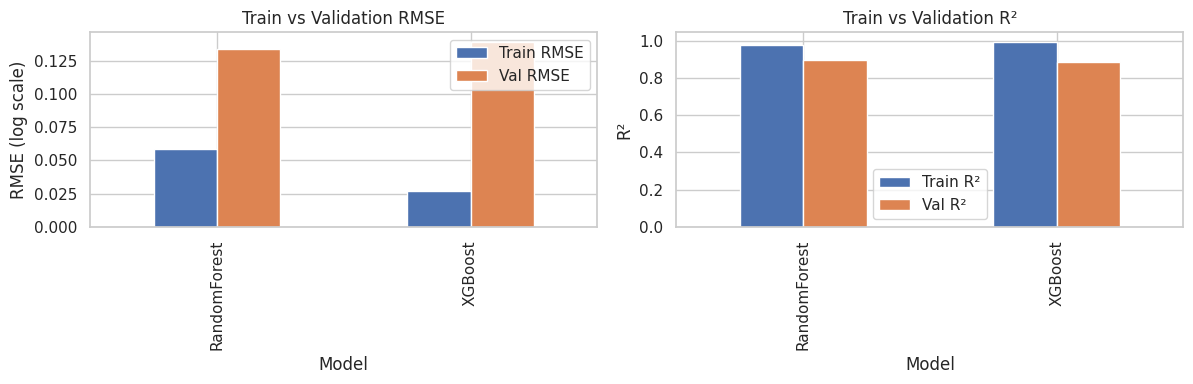

In [27]:
#  Visual Comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_df.plot(x='Model', y=['Train RMSE', 'Val RMSE'], kind='bar', ax=axes[0])
axes[0].set_title('Train vs Validation RMSE')
axes[0].set_ylabel('RMSE (log scale)')

comparison_df.plot(x='Model', y=['Train R²', 'Val R²'], kind='bar', ax=axes[1])
axes[1].set_title('Train vs Validation R²')
axes[1].set_ylabel('R²')
plt.tight_layout()
plt.show()

In [28]:
# Evaluate Best Model on Test Set

best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

test_pred_log = best_model.predict(X_test_encoded)
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, test_pred_log))
test_r2 = r2_score(y_test_log, test_pred_log)

# Convert to dollars
test_pred_dollars = np.expm1(test_pred_log)
actual_dollars = np.expm1(y_test_log)
test_rmse_dollars = np.sqrt(mean_squared_error(actual_dollars, test_pred_dollars))

print(f"Test RMSE (log scale): {test_rmse_log:.4f}")
print(f"Test RMSE (dollars): ${test_rmse_dollars:,.2f}")
print(f"Test R²: {test_r2:.4f}")

Best model: RandomForest
Test RMSE (log scale): 0.1311
Test RMSE (dollars): $27,226.82
Test R²: 0.8990


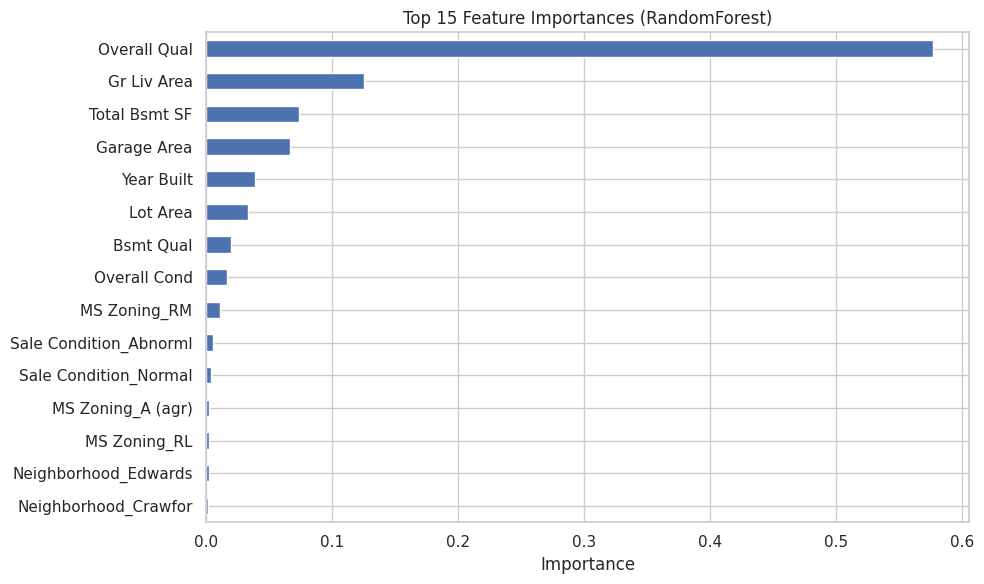

In [29]:
# Feature Importance (Top 15)

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train_encoded.columns)
    top15 = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    top15.plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title(f'Top 15 Feature Importances ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

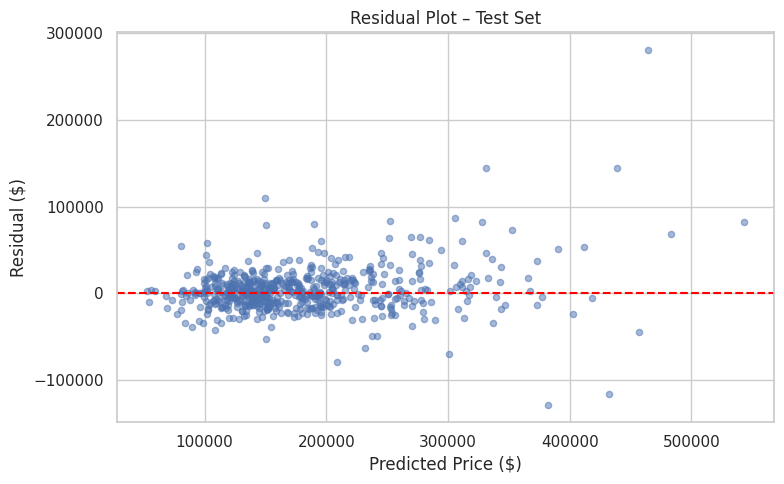

In [30]:
# Residual Plot (Test Set)

residuals = actual_dollars - test_pred_dollars
plt.figure(figsize=(8, 5))
plt.scatter(test_pred_dollars, residuals, alpha=0.5, s=20)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residual Plot – Test Set')
plt.tight_layout()
plt.show()

In [32]:
import joblib

# Serialize Full Pipeline

# Create the original X_train (unencoded) for pipeline fitting
# Re-split X and y to get the raw training data for the pipeline
X_train_pipeline_input, _, y_train_pipeline_input, _ = train_test_split(X, y, test_size=0.40, random_state=42)

# Select only the relevant columns for the pipeline from this raw split
X_train_raw = X_train_pipeline_input[selected_cols].copy()
y_train_raw = y_train_pipeline_input.copy() # Ensure y_train_raw is also from the raw split

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler', StandardScaler())]), numeric_features),
    ('ord', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('encoder', OrdinalEncoder(categories=ordinal_categories))]), ordinal_features),
    ('nom', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), nominal_features)
])

full_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', best_model)
])

# y_train_log is already computed correctly in cell H2aGqTlbG-jr from the appropriate y_train.
full_pipeline.fit(X_train_raw, y_train_log)
joblib.dump(full_pipeline, 'ames_model_pipeline.pkl')
print("Pipeline saved as 'ames_model_pipeline.pkl'")

Pipeline saved as 'ames_model_pipeline.pkl'


In [33]:
# Prompt Versioning (TEMP)

test_queries = [
    "3-bedroom ranch with a big garage in a good neighborhood",
    "Luxury condo with 2000 sqft, built in 2015, near downtown",
    "Fixer-upper with large lot, 2 beds, needs work"
]
print("Test queries for prompt evaluation:")
for q in test_queries:
    print(f"- {q}")
print("\nIn production, these will be sent to the LLM extraction stage.")

Test queries for prompt evaluation:
- 3-bedroom ranch with a big garage in a good neighborhood
- Luxury condo with 2000 sqft, built in 2015, near downtown
- Fixer-upper with large lot, 2 beds, needs work

In production, these will be sent to the LLM extraction stage.
